In [6]:
import h5py
from pathlib import Path
import numpy as np

In [16]:
data_path = Path("/Users/stimpfli/Desktop/prototype_data/poseforge/bulk_data/BO_Gal4_fly2_trial005/segment_000/subsegment_000/processed_simulation_data.h5")
with h5py.File(data_path, "r") as f:
    print("Keys in the HDF5 file:" + str(list(f["postprocessed"].keys())))
    segmaps = f["postprocessed"]["segmentation_labels"][:]
    segments = f["postprocessed"]["segmentation_labels"].attrs["keys"]

# load the video frames as well
video_path = data_path.parent / "processed_nmf_sim_render_flybody_base.mp4"
import cv2
cap = cv2.VideoCapture(str(video_path))
ret = True
frames = []
while ret:
    ret, frame = cap.read()
    if ret:
        frames.append(frame)

frames = np.array(frames)
print("Frames shape:", frames.shape)
cap.release()

Keys in the HDF5 file:['body_segment_states', 'dof_angles', 'keypoint_pos', 'segmentation_labels']
Frames shape: (0,)


OpenCV: Couldn't read video stream from file "/Users/stimpfli/Desktop/prototype_data/poseforge/bulk_data/BO_Gal4_fly2_trial005/segment_000/subsegment_000/processed_nmf_sim_render_flybody_base.mp4"


In [20]:
list(segments).index("lf_trochanterfemur")

22

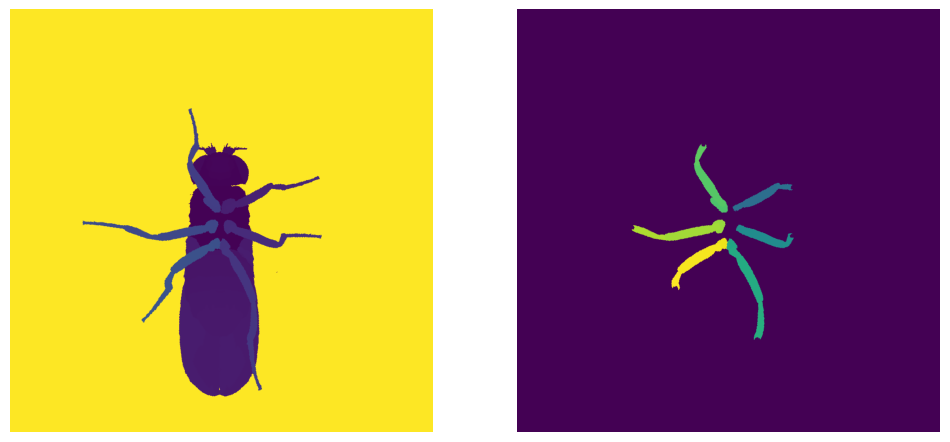

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

selected_original_class_indices = np.array([
    22, 23, 24,
    30, 31, 32,
    38, 39, 40,
    46, 47, 48,
    54, 55, 56,
    62, 63, 64,
    #70, 71, 72,
    #78, 79, 80
    ])


fig, axs = plt.subplots(1, 2, figsize=(12, 6))
frame_id = 100
sel_segmap = segmaps[frame_id].copy()
axs[0].imshow(sel_segmap)
selected_segs_mask = np.isin(sel_segmap, selected_original_class_indices)
sel_segmap[~selected_segs_mask] = 0
axs[1].imshow(sel_segmap)
for ax in axs:
    ax.axis("off")
plt.show()


In [28]:
list([22, 23, 24,
    30, 31, 32,
    38, 39, 40,
    46, 47, 48,
    54, 55, 56,
    62, 63, 64,])

[22, 23, 24, 30, 31, 32, 38, 39, 40, 46, 47, 48, 54, 55, 56, 62, 63, 64]

In [26]:
with h5py.File("/Volumes/upramdya/data/VAS/poseforge/poseforge_contrastive/trial_20260504_tiled2variants/inference/BO_Gal4_fly2_trial005/segment_000/subsegment_000/contrastive_latents.h5", "r") as f:
    print("Keys in the HDF5 file:" + str(list(f.keys())))
    print("Subkeys: ",f["h_features_pooled"].keys())

Keys in the HDF5 file:['h_features_pooled', 'z_features']
Subkeys:  <KeysViewHDF5 ['epoch000_step000500', 'epoch001_step000500', 'epoch003_step000500', 'epoch005_step000500', 'epoch007_step000500', 'epoch009_step000500', 'untrained']>


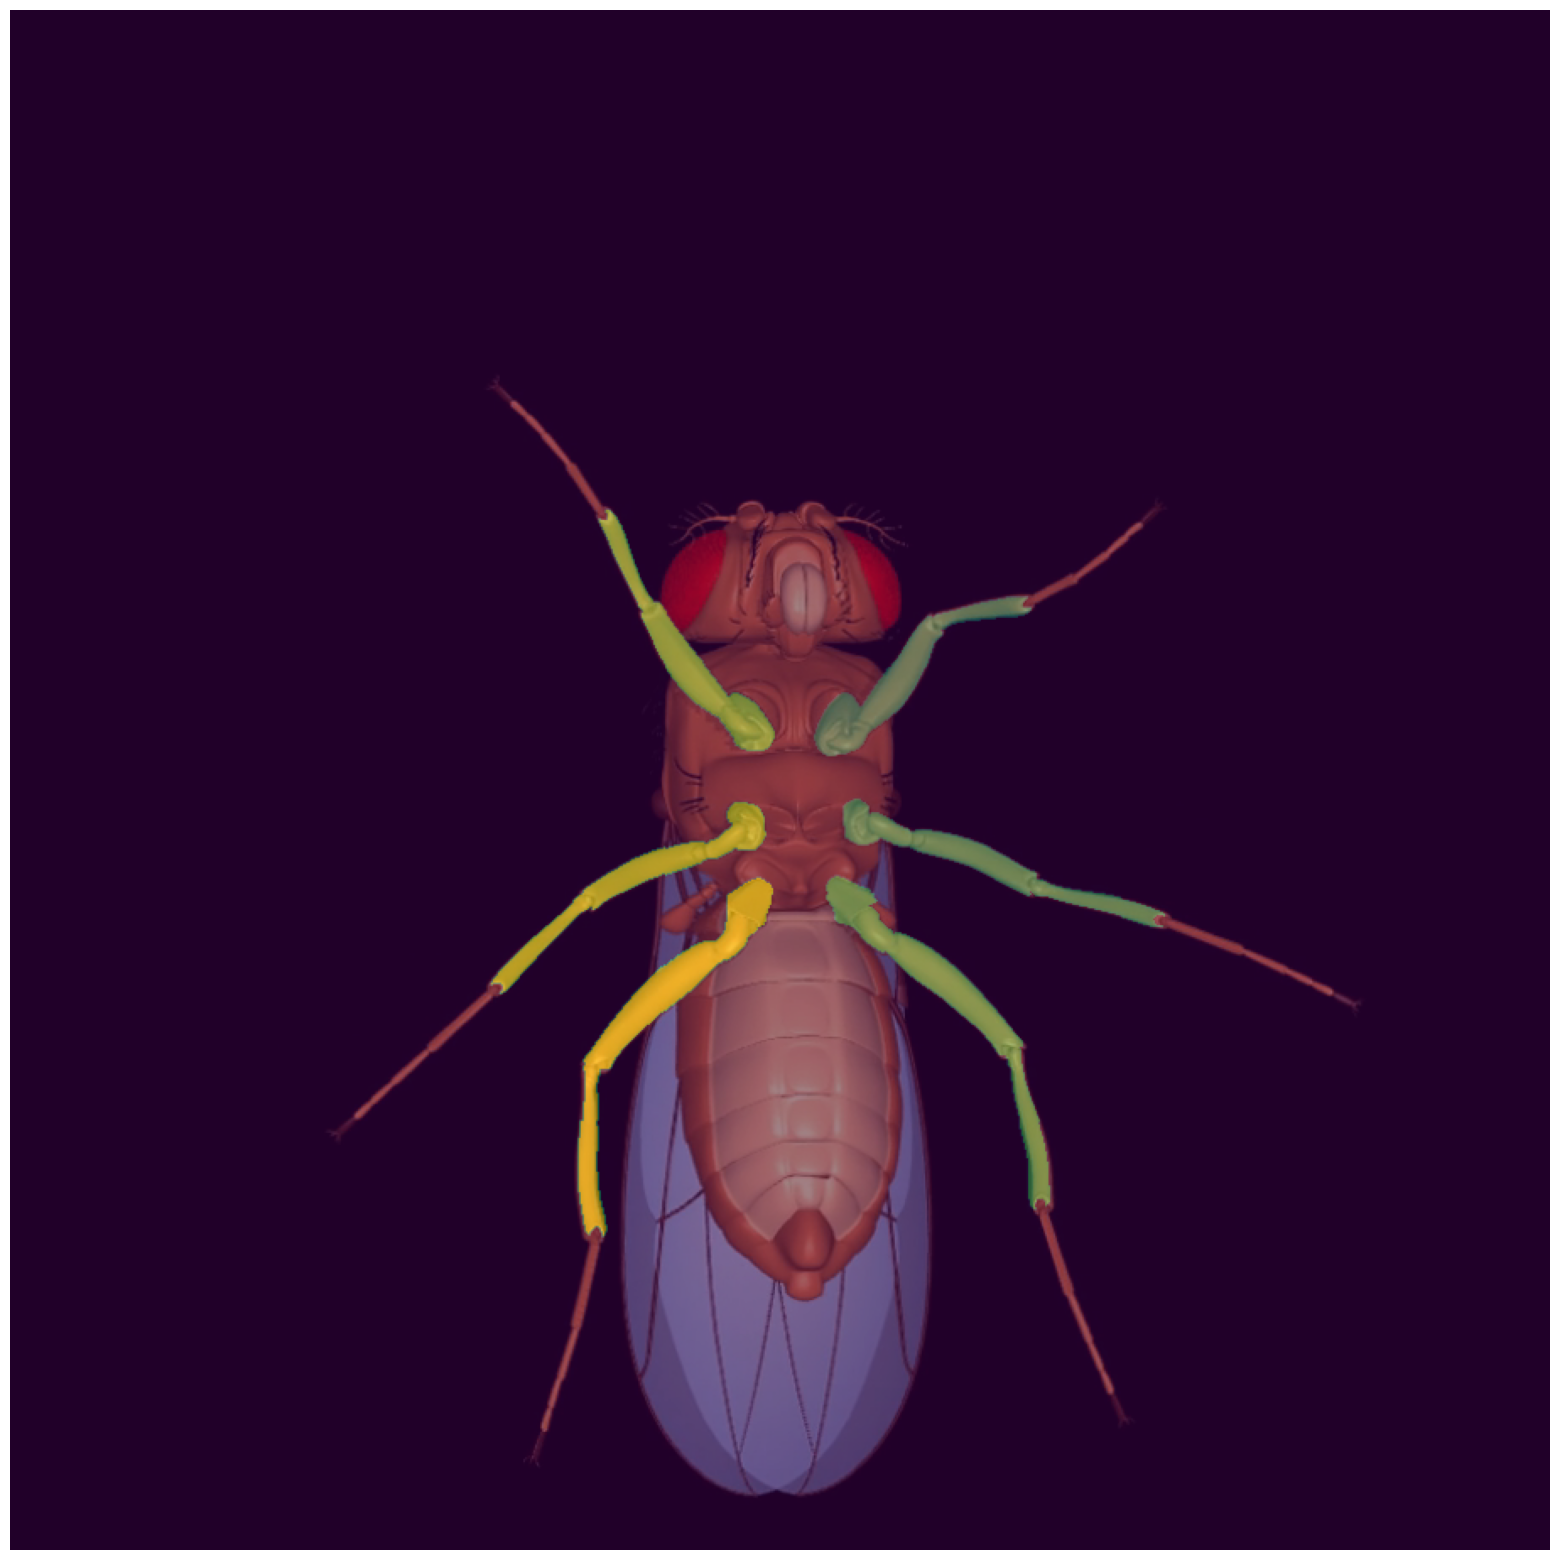

In [ ]:
plt.figure(figsize=(20, 20))
frame = frames[frame_id]
frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)  # Convert from BGR to RGB for correct color display
plt.imshow(frame)
plt.axis("off")
plt.imshow(cv2.resize(sel_segmap, (frame.shape[1], frame.shape[0])), alpha=0.5)

# atomic label

In [ ]:
atomic_label_path = Path("/Users/stimpfli/Downloads/atomic_batches/BO_Gal4_fly4_trial001/atomicbatch00000113_batch00056_variantsgroup04_labels.h5")
with h5py.File(atomic_label_path, "r") as f:
    print("Keys in the atomic label HDF5 file:")
    print(list(f.keys()))
    atomic_segmaps = f["body_seg_maps"][:]
    print("Atomic segmentation maps shape:", atomic_segmaps.shape)

Keys in the atomic label HDF5 file:
['body_seg_maps', 'dof_angles', 'keypoint_pos']
Atomic segmentation maps shape: (32, 912, 912)


In [ ]:
keypoint_predicitons_path = Path("/Volumes/upramdya/data/VAS/poseforge/improve_kpt/20250613-fly1b-005/poseforge_output/keypoints3d_prediction.h5")
def printh5_keys_and_attr_recursively(group, indent=0):
    for key in group.keys():
        item = group[key]
        print("  " * indent + f"Key: {key}, Type: {'Group' if isinstance(item, h5py.Group) else 'Dataset'}")
        if isinstance(item, h5py.Dataset):
            print("  " * (indent + 1) + f"Shape: {item.shape}, Dtype: {item.dtype}")
            for attr_key in item.attrs.keys():
                print("  " * (indent + 2) + f"Attribute: {attr_key}, Value: {item.attrs[attr_key]}")
        elif isinstance(item, h5py.Group):
            printh5_keys_and_attr_recursively(item, indent + 1)

with h5py.File(keypoint_predicitons_path, "r") as f:
    print("Keys in the keypoint predictions HDF5 file:")
    printh5_keys_and_attr_recursively(f)

Keys in the keypoint predictions HDF5 file:
Key: conf_depth, Type: Dataset
  Shape: (1395, 32), Dtype: float32
Key: conf_xy, Type: Dataset
  Shape: (1395, 32), Dtype: float32
Key: pred_depth, Type: Dataset
  Shape: (1395, 32), Dtype: float32
Key: pred_world_xyz, Type: Dataset
  Shape: (1395, 32, 3), Dtype: float32
Key: pred_xy, Type: Dataset
  Shape: (1395, 32, 2), Dtype: float32


In [5]:
annotation_path = Path("/Users/stimpfli/Desktop/prototype_data/poseforge/spotlight-data/20250613-fly1b-005/poseforge_output/keypoints3d_prediction_corrected.h5")
with h5py.File(annotation_path, "r") as f:
    for attrs in f.attrs:
        print(f"File attribute: {attrs} = {f.attrs[attrs]}")
    print("Keys in the annotation HDF5 file:")
    printh5_keys_and_attr_recursively(f)

File attribute: full_resolution = [900 900]
File attribute: inference_size = [256 256]
File attribute: keypoints = ['LFThC' 'LFCTr' 'LFFTi' 'LFTiTa' 'LFClaw' 'LMThC' 'LMCTr' 'LMFTi'
 'LMTiTa' 'LMClaw' 'LHThC' 'LHCTr' 'LHFTi' 'LHTiTa' 'LHClaw' 'RFThC'
 'RFCTr' 'RFFTi' 'RFTiTa' 'RFClaw' 'RMThC' 'RMCTr' 'RMFTi' 'RMTiTa'
 'RMClaw' 'RHThC' 'RHCTr' 'RHFTi' 'RHTiTa' 'RHClaw' 'LPedicel' 'RPedicel']
File attribute: n_modified = 5
File attribute: n_total_frames = 1395
File attribute: source_h5 = /Users/stimpfli/Desktop/prototype_data/poseforge/spotlight-data/20250613-fly1b-005/poseforge_output/keypoints3d_prediction.h5
File attribute: source_video = /Users/stimpfli/Desktop/prototype_data/poseforge/spotlight-data/20250613-fly1b-005/processed/aligned_behavior_video.mkv
File attribute: xy_key = pred_xy
Keys in the annotation HDF5 file:
Key: frame_indices, Type: Dataset
  Shape: (5,), Dtype: int32
Key: keypoints_xy, Type: Dataset
  Shape: (5, 32, 2), Dtype: float32
Key: pred_keypoints_xy, Type: Data